# Train classifiers

This notebook will use the training dataset created by notebook `00c` to train the PU and SVM models.

If training data has been extracted from the source datasets by running the `00c-extract_training_data_global.ipynb` and `00b-extract_grid_data.ipynb` notebooks, set the `use_extracted_data` variable below to `True` to use this dataset instead of the pre-prepared training data from the [Zenodo repository](https://zenodo.org/record/8157691).

## Notebook setup

These cells set some of the important variables and definitions used throughout the notebook, based on the selected config file.

### Config

In [4]:
config_file = "config/.run_config.yml"

In [5]:
from lib.paths import PathConfigManager
pcm = PathConfigManager(config_file, notebook="01")

# =====================
# Filestructure
# =====================

# Base directories
plate_model_dir = pcm.PLATE_MODEL_DIR
points_data_dir = pcm.POINTS_DATA_DIR
output_dir = pcm.OUTPUT_DIR

pcm.create_directories()

# Input data filepaths
regions_filepath = pcm.REGIONS_PATH
training_data_filepath = pcm.TRAINING_DATA_PATH

# =====================
# Notebook scope
# =====================

# Gates for determining scope of notebook run (i.e. which feature sets can be selected from)
use_features = pcm.use_features

# If True, use training data extracted in notebook 00b, 00c
# Else, use pre-prepared training data downloaded from Zenodo
use_extracted_data = pcm.use_extracted_data

# If False, skip training the SVM models
create_svm = pcm.config["create_svm"]

# If False, skip training all regional models (PU and SVM)
create_regional_models = pcm.config["create_regional_models"]

# =====================
# Model training parameters
# =====================

# Timespan for plotting
min_time = pcm.config["timespan"]["min"]
max_time = pcm.config["timespan"]["max"]
times = range(min_time, max_time + 1)

# If this parameter is False, perform feature selection using all data for all models
# If True, perform feature selection for each model individually
use_same_features = pcm.config["use_same_features"]

# If this parameter is False, selected features must be specified below
# Otherwise, they will be selected automatically
automatic_feature_selection = pcm.config["automatic_feature_selection"]

# Random seed for reproducibility
random_seed = pcm.config["random_seed"]

# Number of processes to use
n_jobs = pcm.config["n_jobs"]

# Overwrite any existing output files
overwrite = pcm.config["overwrite_output"]

# Control verbosity level of logging output
verbose = pcm.config["verbose"]

### Imports

In [ ]:
import warnings

import cartopy.crs as ccrs
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from cartopy.mpl.gridliner import (
    LATITUDE_FORMATTER,
    LONGITUDE_FORMATTER,
)
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from pulearn.bagging import BaggingPuClassifier
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import entropy as scipy_entropy
from sklearn.impute import IterativeImputer
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import (
    Pipeline,
    make_pipeline,
)
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from statsmodels.stats.outliers_influence import variance_inflation_factor

from lib.check_files import check_prepared_data
from lib.misc import (
    format_feature_name,
)
from lib.pu import (
    PU_PARAMS,
    COLUMNS_TO_DROP,
    PRESERVATION_COLUMNS,
    # downsample_unlabelled,
)

# Use figure style template in config directory
plt.style.use(pcm.CONFIG_DIR / "thesis.mplstyle")

# Suppress FutureWarning for some versions of pandas
pd.set_option('future.no_silent_downcasting', True)

# Suppress FutureWarning for some versions of Scikit-learn
%env PYTHONWARNINGS=ignore

# Suppress some other warnings
warnings.simplefilter("ignore", ConvergenceWarning)

<frozen importlib._bootstrap>:488: RuntimeWarning: to-Python converter for GPlatesApi::PythonPickle::Impl::Bytes already registered; second conversion method ignored.
<frozen importlib._bootstrap>:488: RuntimeWarning: to-Python converter for GPlatesUtils::Earth already registered; second conversion method ignored.
<frozen importlib._bootstrap>:488: RuntimeWarning: to-Python converter for QString already registered; second conversion method ignored.
<frozen importlib._bootstrap>:488: RuntimeWarning: to-Python converter for GPlatesUtils::UnicodeString already registered; second conversion method ignored.
<frozen importlib._bootstrap>:488: RuntimeWarning: to-Python converter for GPlatesModel::StringContentTypeGenerator<GPlatesModel::XmlAttributeValueFactory> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:488: RuntimeWarning: to-Python converter for GPlatesModel::StringContentTypeGenerator<GPlatesPropertyValues::EnumerationContentFactory> already regist

env: PYTHONWARNINGS=ignore


/var/folders/vn/gbv894gx5fncbnm4wbnf90080000gn/T/ipykernel_45392/3382293809.py:47: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.


### Input and output files

In [7]:
if use_extracted_data:
    print(f"Using extracted training data in {points_data_dir}")
else:
    print(f"Using prepared training data in {pcm.PREPARED_DATA_DIR}")
    prep_dir = check_prepared_data(pcm.PREPARED_DATA_DIR, verbose=True)
    prep_dir = Path(prep_dir)
    grid_data_filepath = prep_dir / "grid_data.csv"
    training_filepath = prep_dir / "training_data_global.csv"

output_deposits = output_dir / "deposits"
figures_dir = output_dir / "feature_selection"
figures_dir.mkdir(parents=True, exist_ok=True)

pu_dir = output_dir / "PU"
pu_dir.mkdir(parents=True, exist_ok=True)
pu_basename = pu_dir / "classifier"

importance_dir = pu_dir / "feature_importance"
importance_dir.mkdir(parents=True, exist_ok=True)
importance_basename = importance_dir / "feature_importance"

if create_svm:
    svm_dir = output_dir / "SVM"
    svm_dir.mkdir(parents=True, exist_ok=True)
    svm_basename = svm_dir / "classifier"

Using extracted training data in /Users/glados/Documents/Not Useless/Documents/University/2026/Honours/Data & Code/PUB-framework-Alfonso/data_extracted/zahirovic2022/polygons_points/trenches_6.0_deg_buffer


### Classifier parameters

In [8]:
# Parameters for models
imputer_params = {
    "random_state": random_seed,
    "add_indicator": False,
}
rf_params = {
    "random_state": random_seed,
    "n_estimators": 50,
    "n_jobs": 1,
}
pu_params = {
    **PU_PARAMS,
    "n_jobs": n_jobs,
    "random_state": random_seed,
    "n_estimators": 50,
    "balanced_subsample": True,
}
svm_params = {
    "kernel": "rbf",
    "probability": True,
    "random_state": random_seed,
}

Define model and preprocessing pipeline:

In [9]:
pu_model = BaggingPuClassifier(
    RandomForestClassifier(**rf_params),
    **pu_params
)
preprocessing = make_pipeline(
    IterativeImputer(**imputer_params),
    RobustScaler(),
    VarianceThreshold(),
)
pu_pipeline = Pipeline([("preprocessing", preprocessing), ("classifier", pu_model)])
pu_pipeline.set_output(transform="pandas")

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('iterativeimputer', ...), ('robustscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,estimator,None
,missing_values,nan
,sample_posterior,False


## Training data

These cells load and plot the training data.

In [10]:
data = pd.read_csv(training_data_filepath)

data.columns

Index(['present_lon', 'present_lat', 'age (Ma)', 'Cu (Mt)', 'source', 'label',
       'plate_id', 'lon', 'lat', 'overriding_plate_id', 'lab_depth (km)',
       'sublithospheric_cold_anomaly_thickness (km)',
       'cold_anomaly_magnitude (K)',
       'temperature_deviation_avg_0-400km_rolling_50ma (K)',
       'radial_velocity_lab (cm/yr)', 'temperature_deviation_lab (K)',
       'tangential_speed_lab (cm/yr)',
       'radial_tangential_ratio_lab (unitless)',
       'radial_tangential_ratio_lab+40km (unitless)',
       'radial_tangential_ratio_lab+80km (unitless)',
       'radial_tangential_ratio_lab+120km (unitless)',
       'east_plate_velocity (cm/yr)', 'north_plate_velocity (cm/yr)',
       'plate_acceleration (cm/yr/Myr)',
       'mantle_relative_east_velocity_lab (cm/yr)',
       'mantle_relative_north_velocity_lab (cm/yr)',
       'mantle_relative_speed_lab (cm/yr)',
       'relative_velocity_parallel_to_plate_lab (cm/yr)',
       'relative_velocity_transverse_to_plate_lab (cm/y

### Columns to drop

In [11]:
# Drop individual water/carbon components, only use totals
component_columns = {
    "base_lithosphere_water_thickness (m)",
    "sedimentary_bound_water_thickness (m)",
    "sedimentary_pore_water_thickness (m)",
    "mantle_lithosphere_water_thickness (m)",
    "crustal_pore_water_thickness (m)",
    "crustal_bound_water_thickness (m)",
    "subducted_carbonate_volume (m)",
    "carbonate_carbon_density (t/m^2)",
    "carbonate_thickness (m)",
    "crustal_carbon_density (t/m^2)",
}
# Use orthogonal/parallel velocity vector components
component_columns |= {
    "subducting_plate_absolute_velocity (cm/yr)",
    "convergence_rate (cm/yr)",
    "trench_velocity (cm/yr)",
}
# Drop oceanic crust thickness and convergence rate,
# only use slab flux (product of the two components)
component_columns |= {
    "convergence_rate_orthogonal (cm/yr)",
    # "seafloor_age (Ma)",
    "plate_thickness (m)",
}
# Drop orthogonal components of velocity to prevent spatial leakage;
# use only overall magnitude
component_columns |= {
    component for component in data.columns if "east" in component or "north" in component
}

### Load training data

In [12]:
data = pd.read_csv(training_data_filepath)

# Remove duplicate points
# Duplicates arise from a one-to-many overriding-plate
# spatial join in combine_point_data() (notebook 00b).
# Deduplication prevents model bias from over-representation of certain locations.
data = data.drop_duplicates(subset=["lon", "lat", "age (Ma)"], keep="first")

# Skip regions with < 50 deposits
regions_to_skip = set()
for region, subset in data.groupby("region"):
    if (subset["label"] == "positive").sum() < 50:
        regions_to_skip.add(region)
data = data[~data["region"].isin(regions_to_skip)]

# # Equal number of positive and unlabelled samples      <--- ????????
# negatives = data[data["label"] == "negative"]
# tmp = data[data["label"] != "negative"]
# tmp_downsampled = downsample_unlabelled(
#     tmp,
#     random_state=random_seed,
# )
# data = pd.concat((tmp_downsampled, negatives))
df_subset = cleaned = data.drop(
    columns=list(COLUMNS_TO_DROP | PRESERVATION_COLUMNS | component_columns),
    errors="ignore",
)
# del tmp, tmp_downsampled

print("Training data summary:")
print(data.groupby(["region", "label"]).size())
print("\nOverall class distribution:")
print(data.groupby(["label"]).size())

Training data summary:
region          label     
East Asia       negative         8
                positive       142
                unlabelled    6924
North America   negative        51
                positive       283
                unlabelled    7106
South America   negative       641
                positive       160
                unlabelled    6790
Southeast Asia  negative         2
                positive       123
                unlabelled    4420
Tethys          negative        11
                positive       281
                unlabelled    5587
dtype: int64

Overall class distribution:
label
negative        713
positive        989
unlabelled    30827
dtype: int64


### Plot deposit locations

This cell plots the locations of the deposits in the training dataset, saving the image in the `output_dir` directory.

/Users/glados/opt/anaconda3/envs/prospectivity/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
/Users/glados/opt/anaconda3/envs/prospectivity/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
/Users/glados/opt/anaconda3/envs/prospectivity/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
/Users/glados/opt/anaconda3/envs/prospectivity/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
/Users/glados/opt/anaconda3/envs/prospectivity/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
/Users/glados/opt/anaconda3/envs/prospectivity/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
/Users/glados/op

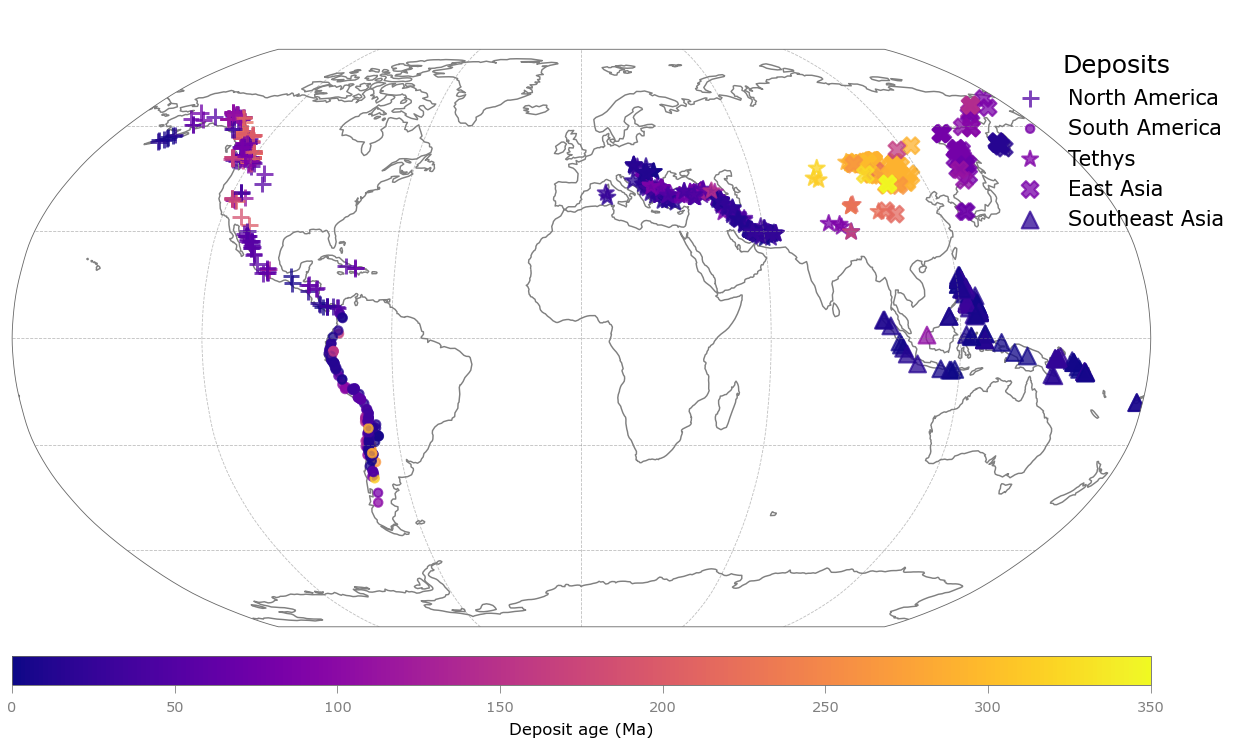

In [13]:
deposits      = data[data["label"] == "positive"]
valid_regions = set(data["region"].unique())

projection = ccrs.Robinson()
transform  = ccrs.PlateCarree()

markers = {
    "North America": "+",
    "South America": ".",
    "Tethys": "*",
    "East Asia": "X",
    "Southeast Asia": "^",
    "Other": "o",
}
vmin, vmax = min_time, max_time
cmap = "plasma"
mappable = ScalarMappable(Normalize(vmin, vmax), cmap=cmap)

fig, ax = plt.subplots(
    figsize=(10, 5),
    subplot_kw={"projection": projection},
)
ax.set_global()
gl = ax.gridlines(
    draw_labels=False,
    xformatter=LONGITUDE_FORMATTER,
    yformatter=LATITUDE_FORMATTER,
    linestyle="dashed",
    linewidth=0.4,
    alpha=0.5,
    color="grey",
)
cax = fig.add_axes(
    [
        ax.get_position().x0,
        ax.get_position().y0 * 0.3,
        ax.get_position().width,
        ax.get_position().height * 0.05,
    ]
)
for region, marker in markers.items():
    if region not in valid_regions:
        continue
    subset = deposits[deposits["region"] == region]
    scat = ax.scatter(
        "present_lon",
        "present_lat",
        c="age (Ma)",
        data=subset,
        marker=marker,
        s=65,
        alpha=0.75,
        transform=transform,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        zorder=1,
        label=region,
    )
ax.coastlines(zorder=0, color="grey", linewidth=0.7)
cbar = fig.colorbar(
    mappable,
    cax=cax,
    orientation="horizontal",
)
cbar.ax.set_xlabel("Deposit age (Ma)")
fig.legend(
    title="Deposits",
    loc=(0.8, 0.68),
    framealpha=0.9,
    fontsize=10,
    title_fontsize=12,
)

for ext in (".pdf", ".png"):
    fig.savefig(output_deposits.with_suffix(ext), dpi=400, bbox_inches="tight")

## Global PU model features

### Wrangle training data

In [ ]:
# Wrangle the training data to the required format
train_pu = cleaned[cleaned["label"].isin({"positive", "unlabelled"})]
x_pu = train_pu.drop(columns="label")
y_pu = train_pu["label"].replace({"positive": 1, "unlabelled": 0}).astype("int")

### Feature analysis

#### Feature correlation

We consider features with a Spearman's correlation $|r| \geq 0.8$ to be highly correlated and remove them.

In [ ]:
cutoff_value = 0.8
cluster_threshold = 1 - cutoff_value

Z = linkage(
    clone(preprocessing).fit_transform(x_pu).T,
    method="single",
    metric=lambda x, y: 1.0 - np.abs(spearmanr(x, y).statistic),
)

cluster_ids = fcluster(Z, cluster_threshold, criterion="distance")
clusters = {
    cluster_id: list(x_pu.columns[cluster_ids == cluster_id])
    for cluster_id in np.unique(cluster_ids)
}

In [ ]:
# -- Plotting functions for dendrogram and mutual information bar chart, used in feature selection step below --

def plot_dendrogram(Z, clusters, feature_names, title="", filename=None):
    fig_dims = (5.91, max(3.65, len(feature_names) * 0.17))
    fig, ax = plt.subplots(figsize=fig_dims)
    dendro = dendrogram(
        Z,
        orientation="right",
        labels=[format_feature_name(i, bold=True) for i in feature_names],
        ax=ax,
        color_threshold=cluster_threshold,
    )
    ax.axvline(
        cluster_threshold,
        linestyle="dashed",
        color="red",
        zorder=10,
        label=f"Cutoff value ({cutoff_value:0.1f})\n({len(clusters)} features)",
    )
    ax.grid(linestyle="dashed", color="lightgrey", axis="x")
    ax.set_xticks(ax.get_xticks(), [f"{1 - i:0.1f}" for i in ax.get_xticks()])
    ax.set_xlabel(r"Spearman's $|r|$")
    for i, j in zip(ax.get_ymajorticklabels(), dendro["leaves_color_list"]):
        i.set_color(j)
        i.set_fontweight("bold")
        i.set_fontsize(8)
    ax.legend(loc="best")
    if title:
        ax.set_title(title)
    if filename is not None:
        for ext in (".pdf", ".png"):
            fig.savefig(f"{filename}{ext}", bbox_inches="tight")
    return dendro


def plot_mi(dendro, mi_series, feature_names, title="", filename=None):
    leaf_indices = dendro["leaves"]
    leaf_colours = dendro["leaves_color_list"]
    ordered_features = [feature_names[i] for i in leaf_indices]
    ordered_mi = [mi_series[feature_names[i]] for i in leaf_indices]

    fig_dims = (5.91, max(3.65, len(feature_names) * 0.17))
    fig, ax = plt.subplots(figsize=fig_dims)
    ax.barh(
        range(len(ordered_features)),
        ordered_mi,
        color=leaf_colours,
        edgecolor="none",
    )
    ax.set_yticks(range(len(ordered_features)))
    ax.set_yticklabels(
        [format_feature_name(f, bold=True) for f in ordered_features],
    )
    for i, j in zip(ax.get_ymajorticklabels(), dendro["leaves_color_list"]):
        i.set_color(j)
        i.set_fontweight("bold")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Normalised mutual information")
    ax.grid(linestyle="dashed", color="lightgrey", axis="x")
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title)
    if filename is not None:
        for ext in (".pdf", ".png"):
            fig.savefig(filename.with_suffix(ext), bbox_inches="tight")


def plot_combined(Z, clusters, mi_series, feature_names, title="", filename=None):
    fig_dims = (5.91, max(3.65, len(feature_names) * 0.17))
    fig, (ax_mi, ax_dendro) = plt.subplots(
        1, 2,
        figsize=fig_dims,
        sharey=True,
        gridspec_kw={"width_ratios": [1, 3], "wspace": 0.1},
    )
    _dendro = dendrogram(
        Z,
        orientation="right",
        labels=[format_feature_name(i, bold=True) for i in feature_names],
        ax=ax_dendro,
        color_threshold=cluster_threshold,
    )
    ax_dendro.axvline(
        cluster_threshold,
        linestyle="dashed",
        color="red",
        zorder=10,
        label=f"Cutoff value ({cutoff_value:0.1f})\n({len(clusters)} features)",
    )
    ax_dendro.grid(linestyle="dashed", color="lightgrey", axis="x")
    ax_dendro.set_xlim(0, 1)
    ax_dendro.set_xticks(ax_dendro.get_xticks(), [f"{1 - i:0.1f}" for i in ax_dendro.get_xticks()])
    ax_dendro.set_xlabel(r"Spearman's $|r|$")
    ax_dendro.tick_params(labelleft=False, left=False)
    ax_dendro.legend(loc="best")
    if title:
        ax_dendro.set_title(title)

    leaf_colours = _dendro["leaves_color_list"]
    ordered_features = [feature_names[i] for i in _dendro["leaves"]]
    ordered_mi = [mi_series[f] for f in ordered_features]

    y_pos = np.arange(len(ordered_features)) * 10 + 5
    mi_upper = np.ceil(max(ordered_mi) * 10) / 10
    ax_mi.barh(y_pos, ordered_mi, height=9, color=leaf_colours, edgecolor="none")
    ax_mi.set_xlim(0, mi_upper)
    ax_mi.set_xlabel("Mutual information\nwith deposit label")
    for label, color in zip(ax_mi.get_ymajorticklabels(), leaf_colours):
        label.set_color(color)
        label.set_fontweight("bold")
        label.set_fontsize(7)
    ax_mi.grid(linestyle="dashed", color="lightgrey", axis="x")
    ax_mi.set_axisbelow(True)

    if filename is not None:
        for ext in (".pdf", ".png"):
            fig.savefig(f"{filename}{ext}", bbox_inches="tight")

#### Dendrogram

This can be illustrated using a dendrogram:

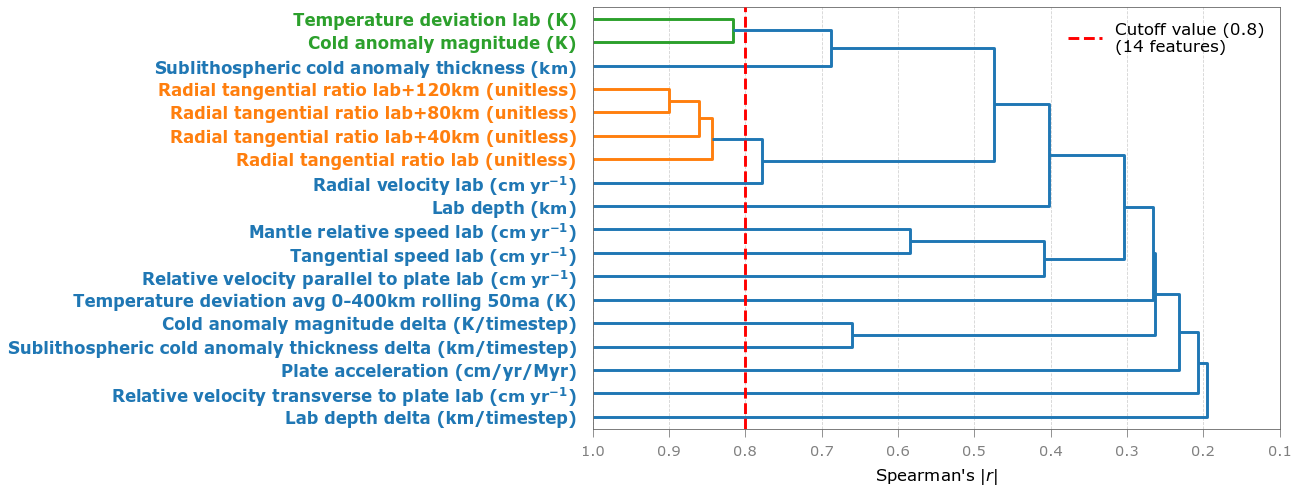

In [ ]:
dendrogram_filename = figures_dir / "dendrogram"

dendro = plot_dendrogram(Z, clusters, x_pu.columns, filename=dendrogram_filename)

The following groups of features are highly correlated:

In [ ]:
for cluster_id in sorted(clusters.keys()):
    cluster_features = clusters[cluster_id]
    print(f"Cluster #{cluster_id}:")
    for feature in cluster_features:
        print(f"  - {feature}")

Cluster #1:
  - sublithospheric_cold_anomaly_thickness_delta (km/timestep)
Cluster #2:
  - cold_anomaly_magnitude_delta (K/timestep)
Cluster #3:
  - tangential_speed_lab (cm/yr)
Cluster #4:
  - mantle_relative_speed_lab (cm/yr)
Cluster #5:
  - relative_velocity_parallel_to_plate_lab (cm/yr)
Cluster #6:
  - radial_tangential_ratio_lab (unitless)
  - radial_tangential_ratio_lab+40km (unitless)
  - radial_tangential_ratio_lab+80km (unitless)
  - radial_tangential_ratio_lab+120km (unitless)
Cluster #7:
  - radial_velocity_lab (cm/yr)
Cluster #8:
  - cold_anomaly_magnitude (K)
  - temperature_deviation_lab (K)
Cluster #9:
  - sublithospheric_cold_anomaly_thickness (km)
Cluster #10:
  - lab_depth (km)
Cluster #11:
  - temperature_deviation_avg_0-400km_rolling_50ma (K)
Cluster #12:
  - plate_acceleration (cm/yr/Myr)
Cluster #13:
  - relative_velocity_transverse_to_plate_lab (cm/yr)
Cluster #14:
  - lab_depth_delta (km/timestep)


#### Cutoff threshold

We can also visualise the number of features as a function of the Spearman's $|r|$ cutoff threshold:

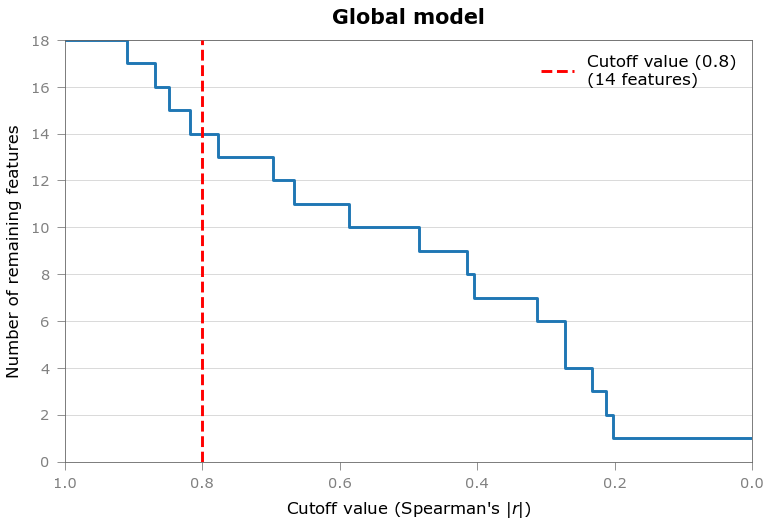

In [ ]:
cutoff_nfeatures_filename = figures_dir / "cutoff_nfeatures"

thresh_vals = np.linspace(0, 1, 100)
thresh_clusters = np.array([
    len(np.unique(fcluster(Z, 1 - t, criterion="distance")))
    for t in thresh_vals
])

fig_dims = (5.91, 3.65)
fix, ax = plt.subplots(figsize=fig_dims)
ax.step(thresh_vals, thresh_clusters, where="post")
ax.axvline(
    cutoff_value,
    linestyle="dashed",
    color="red",
    zorder=10,
    label=f"Cutoff value ({cutoff_value:0.1f})\n({len(clusters)} features)",
)
ax.set_xlim(thresh_vals.max(), thresh_vals.min())
ax.set_ylim(0, None)
ax.grid(linestyle="-", color="lightgrey", axis="y")
ax.legend(loc="best")
ax.set_xlabel(r"Cutoff value (Spearman's $|r|$)")
ax.set_ylabel("Number of remaining features")
ax.set_title("Global model")

for ext in (".pdf", ".png"):
    fig.savefig(f"{cutoff_nfeatures_filename}{ext}", bbox_inches="tight")

#### Mutual information

Another useful metric is mutual information, which tells us how much each feature has in common with the distribution of positive labels:

In [ ]:
# Compute MI scores (sklearn uses nats, consistent with scipy default)
X_preprocessed = clone(preprocessing).fit_transform(x_pu)
mi_scores = mutual_info_classif(
    X_preprocessed,
    y_pu,
    random_state=random_seed,
)

# Normalise by target entropy so axis is bounded [0, 1]
# MI / H(Y) represents fraction of target uncertainty explained by each feature
p = y_pu.mean()
target_entropy = scipy_entropy([p, 1 - p])
mi_normalised = mi_scores / target_entropy
mi_series = pd.Series(mi_normalised, index=x_pu.columns)

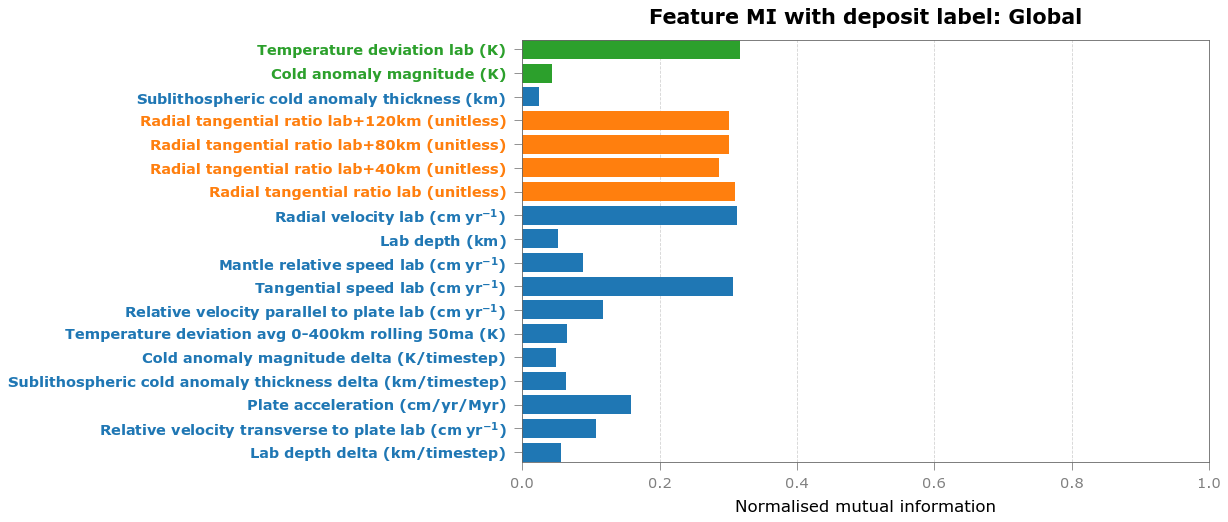

In [ ]:
mi_filename = figures_dir / "mutual_information"

plot_mi(dendro, mi_series, x_pu.columns, title="Feature MI with deposit label: Global", filename=mi_filename)

#### Combined plot

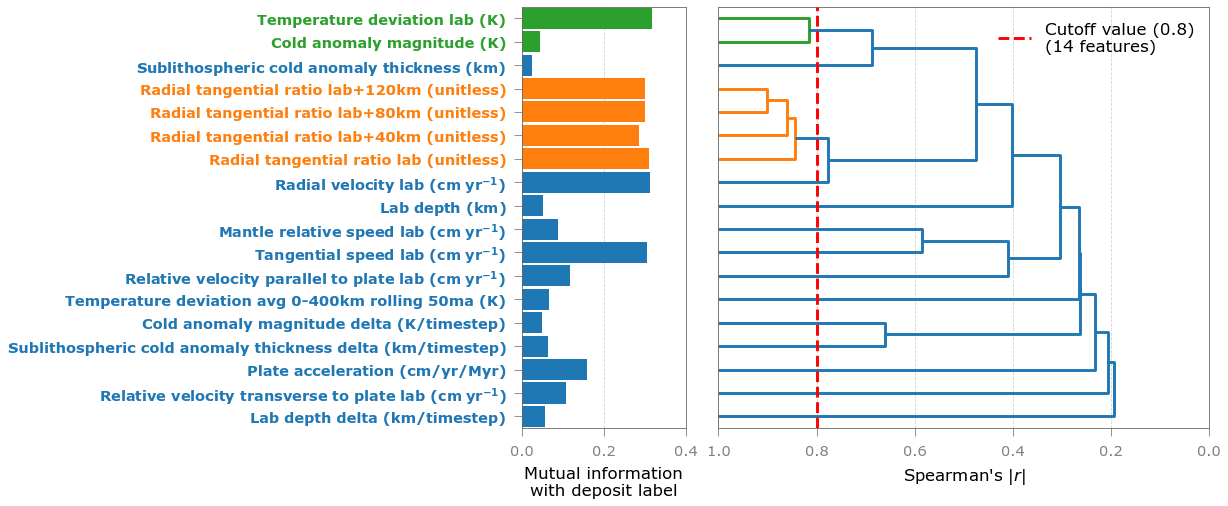

In [ ]:
combined_filename = figures_dir / "dendrogram_mi_combined"

plot_combined(Z, clusters, mi_series, x_pu.columns, title="Global model", filename=combined_filename)

#### Mutual info with other features
To determine whether our features are truly independent, we compare their mutual information, i.e., "how much does each of these features tell you about each of the other features?"

In [ ]:
features = x_pu.columns
n = len(features)
mi_matrix = np.zeros((n, n))

for i, col in enumerate(x_pu.columns):
    mi_scores = mutual_info_regression(
        x_pu,
        x_pu[col],
        random_state=random_seed
    )
    mi_matrix[i, :] = mi_scores

# Symmetrise — should be symmetric in theory but kNN estimates introduce asymmetry
mi_matrix = (mi_matrix + mi_matrix.T) / 2

# Normalise to [0, 1] by dividing by max off-diagonal value
np.fill_diagonal(mi_matrix, 0)
mi_matrix /= mi_matrix.max()

mi_df = pd.DataFrame(mi_matrix, index=features, columns=features)

/Users/glados/opt/anaconda3/envs/prospectivity/lib/python3.13/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
/Users/glados/opt/anaconda3/envs/prospectivity/lib/python3.13/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix


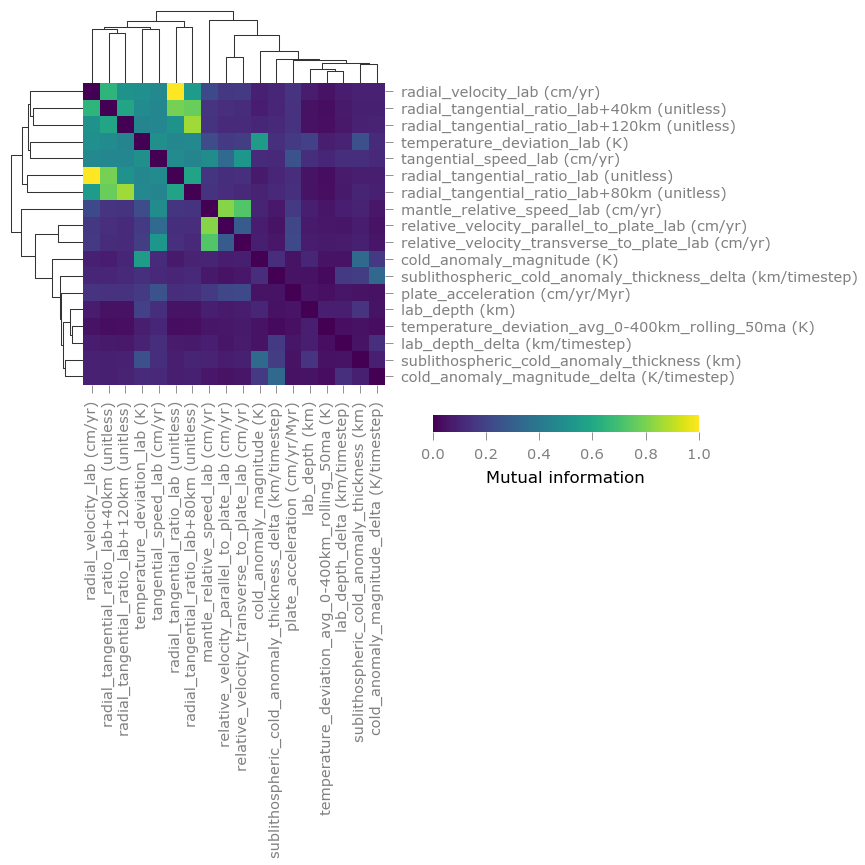

In [ ]:
g = sns.clustermap(
    mi_df,
    cmap="viridis",
    vmin=0, vmax=1,
    annot=False,
    figsize=(5.91, 5.91),
    method="average",
    xticklabels=True,
    yticklabels=True,
    cbar_kws={"label": "Mutual information", "location": "bottom", "shrink": 0.8}
)
# g.ax_heatmap.set_position([0.2, 0.2, 0.6, 0.6])
g.ax_cbar.set_position([0.5, 0.5, 0.3, 0.02])

#### Variance inflation factor

As a sanity-check, we take a look at the whole data set to see which features can be constructed as linear combinations of other features. This step is less useful when using a tree-based classifier like a random forest (as we do here), but it is still interesting. If a feature's VIF is greater than five, it's too collinear and not worth keeping.

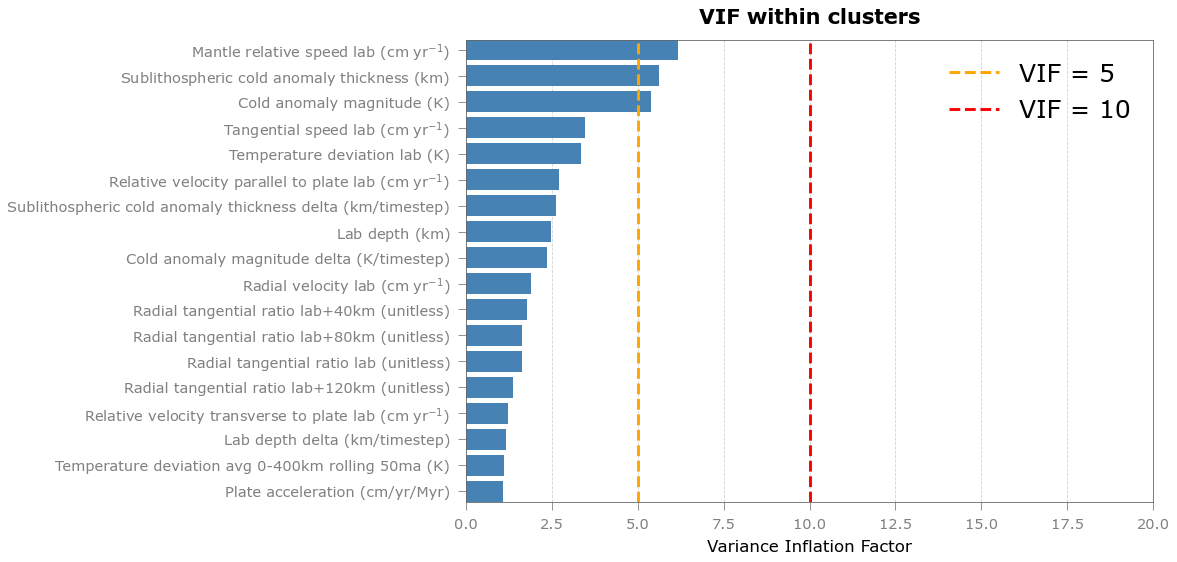

In [ ]:


X_all = pd.DataFrame(
    clone(preprocessing).fit_transform(x_pu),
    columns=x_pu.columns,
)

# VIF within each cluster (undefined/trivially 1 for singletons)
vif_records = [
    {"feature": col, "VIF": variance_inflation_factor(X_all.values, i)}
    for i, col in enumerate(X_all.columns)
]

vif_df = (
    pd.DataFrame(vif_records)
    .sort_values(["VIF"], ascending=[True])
    .reset_index(drop=True)
)

# Plot
vif_filename = figures_dir / "full_vif"

fig, ax = plt.subplots(figsize=(5.91, max(4, len(vif_df) * 0.17)))
ax.barh(
    range(len(vif_df)),
    vif_df["VIF"],
    color="steelblue",
    edgecolor="none",
)
ax.axvline(5, linestyle="dashed", color="orange", label="VIF = 5")
ax.axvline(10, linestyle="dashed", color="red", label="VIF = 10")
ax.set_yticks(range(len(vif_df)))
ax.set_yticklabels([format_feature_name(f) for f in vif_df["feature"]])
ax.set_xlabel("Variance Inflation Factor")
ax.set_xlim(0, 20)
ax.set_title("Full VIF ranking")
ax.legend(fontsize=10)
ax.grid(linestyle="dashed", color="lightgrey", axis="x")
ax.set_axisbelow(True)

for ext in (".pdf", ".png"):
    fig.savefig(f"{vif_filename}{ext}", dpi=350, bbox_inches="tight")

### Select features

Now that we know which groups of features are highly correlated and share information, we can select one feature from each group, either manually or automatically.

In [ ]:
# if automatic_feature_selection:
if automatic_feature_selection:
    selected_features = [
        max(clusters[cluster_id], key=lambda f: mi_series.get(f, 0.0))
        for cluster_id in sorted(np.unique(cluster_ids))
    ]
else:
    if use_features("subduction"):
        selected_features |= {
            "distance_from_trench_start (km)",
            "distance_to_trench_edge (km)",
            "convergence_rate_parallel (cm/yr)",
            "subducting_plate_absolute_velocity_parallel (cm/yr)",
            "trench_velocity_obliquity (degrees)",
            "trench_velocity_parallel (cm/yr)",
            "distance_to_trench (km)",
            "seafloor_age (Ma)",
            "slab_flux (m^2/yr)",
            "slab_dip (degrees)",
            "trench_velocity_orthogonal (cm/yr)",
            "seafloor_spreading_rate (km/Myr)",
        }
    if use_features("carbonate"):
        selected_features |= {
            "sediment_thickness (m)",
            "subducted_sediment_volume (m)",
            "total_carbon_density (t/m^2)",
        }
    if use_features("crustal"):
        selected_features |= {
            "crustal_thickness_mean (m)",
            "crustal_thickness_min (m)",
        }
    if use_features("mantle"):
        selected_features |= {
            "lab_depth (km)",
            "lab_depth_delta (km/timestep)",

            "sublithospheric_cold_anomaly_thickness (km)",
            "sublithospheric_cold_anomaly_thickness_delta (km/timestep)",
            "cold_anomaly_magnitude_delta (K/timestep)",

            "temperature_deviation_lab (K)",
            "temperature_deviation_avg_0-400km_rolling_50ma (K)",

            # "radial_velocity_lab (cm/yr)",
            "tangential_speed_lab (cm/yr)",
            "radial_tangential_ratio_lab (unitless)",
            "radial_tangential_ratio_lab+40km (unitless)",
            "radial_tangential_ratio_lab+80km (unitless)",
            "radial_tangential_ratio_lab+120km (unitless)",

            "relative_velocity_transverse_to_plate_lab (cm/yr)",
            "relative_velocity_parallel_to_plate_lab (cm/yr)",
            # "mantle_relative_speed (cm/yr)",

            "plate_acceleration (cm/yr/Myr)",
        }

print(f"Selected {len(selected_features)} features:")
for f in selected_features:
    print(f"  - {f}")

selected_features_basename = output_dir / "selected_features"
pd.DataFrame({"selected_features": selected_features}).to_csv(
    selected_features_basename.with_suffix(".csv"),
    index=False,
)

Selected 15 features:
  - lab_depth (km)
  - lab_depth_delta (km/timestep)
  - sublithospheric_cold_anomaly_thickness (km)
  - sublithospheric_cold_anomaly_thickness_delta (km/timestep)
  - cold_anomaly_magnitude_delta (K/timestep)
  - temperature_deviation_lab (K)
  - temperature_deviation_avg_0-400km_rolling_50ma (K)
  - tangential_speed_lab (cm/yr)
  - radial_tangential_ratio_lab (unitless)
  - radial_tangential_ratio_lab+40km (unitless)
  - radial_tangential_ratio_lab+80km (unitless)
  - radial_tangential_ratio_lab+120km (unitless)
  - relative_velocity_transverse_to_plate_lab (cm/yr)
  - relative_velocity_parallel_to_plate_lab (cm/yr)
  - plate_acceleration (cm/yr/Myr)


## Train regional models

#### Plots

Region: East Asia
label
positive       142
unlabelled    6924
dtype: int64
Region: North America
label
positive       283
unlabelled    7106
dtype: int64
Region: South America
label
positive       160
unlabelled    6790
dtype: int64
Region: Southeast Asia
label
positive       123
unlabelled    4420
dtype: int64
Region: Tethys
label
positive       281
unlabelled    5587
dtype: int64


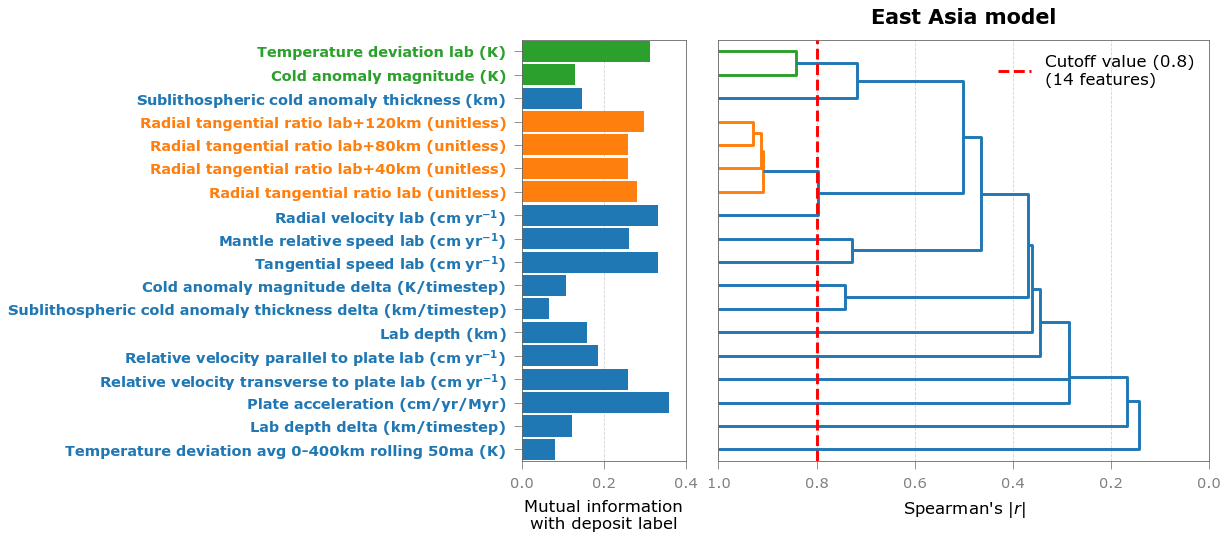

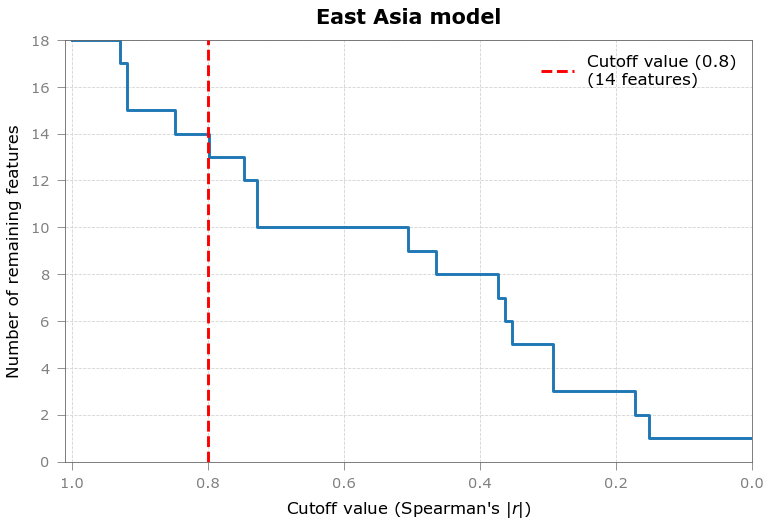

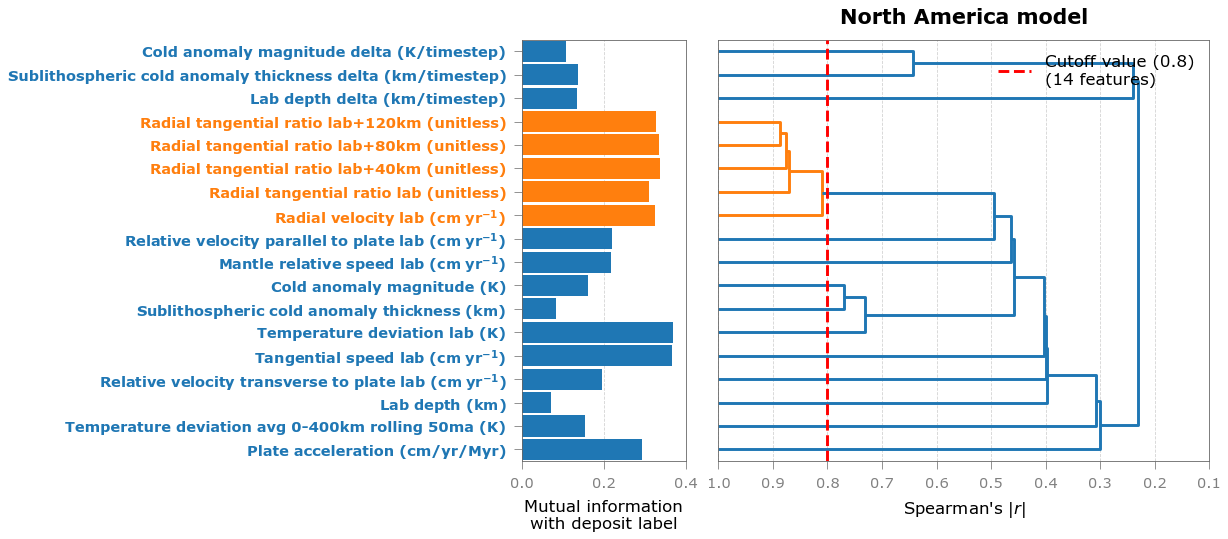

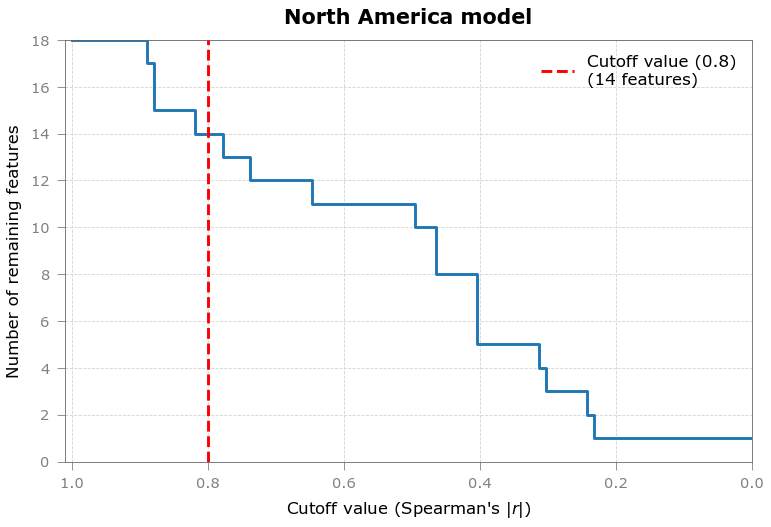

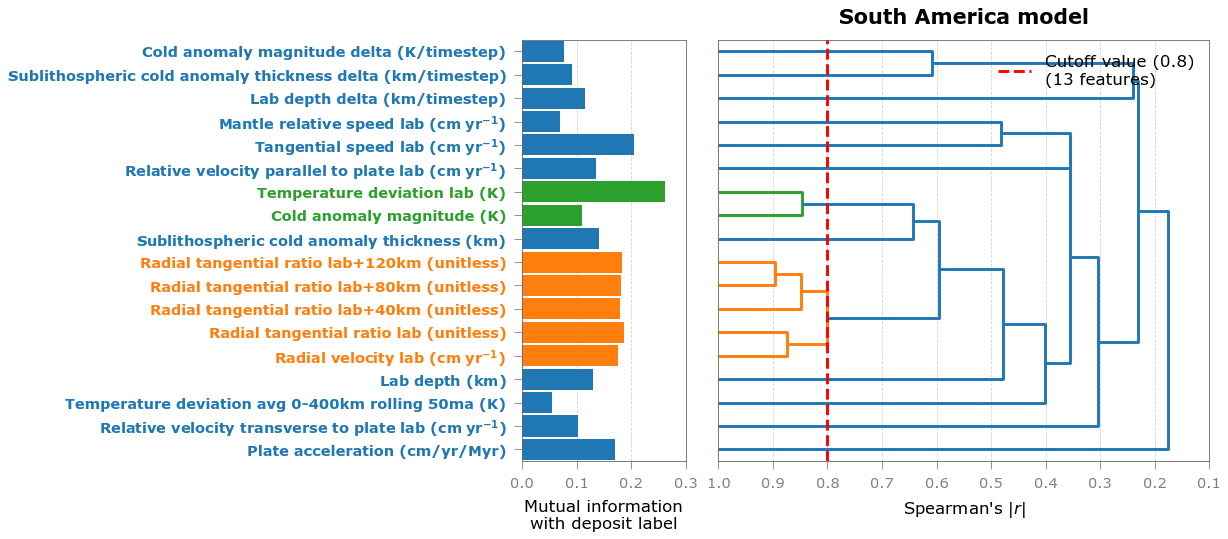

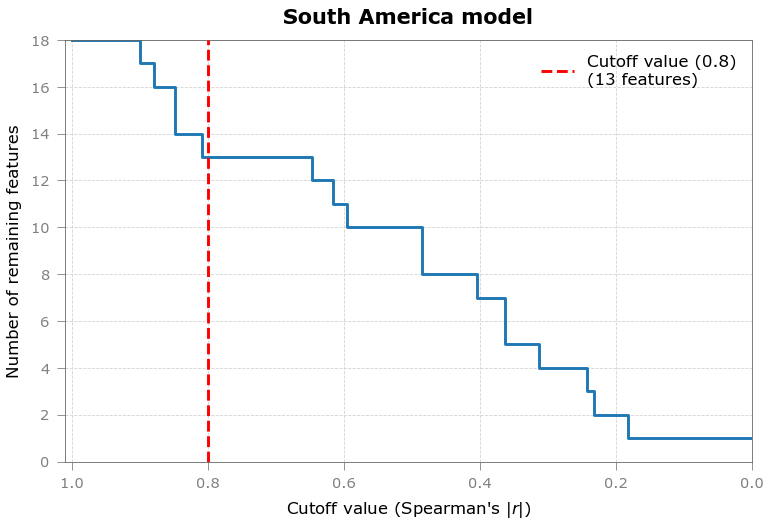

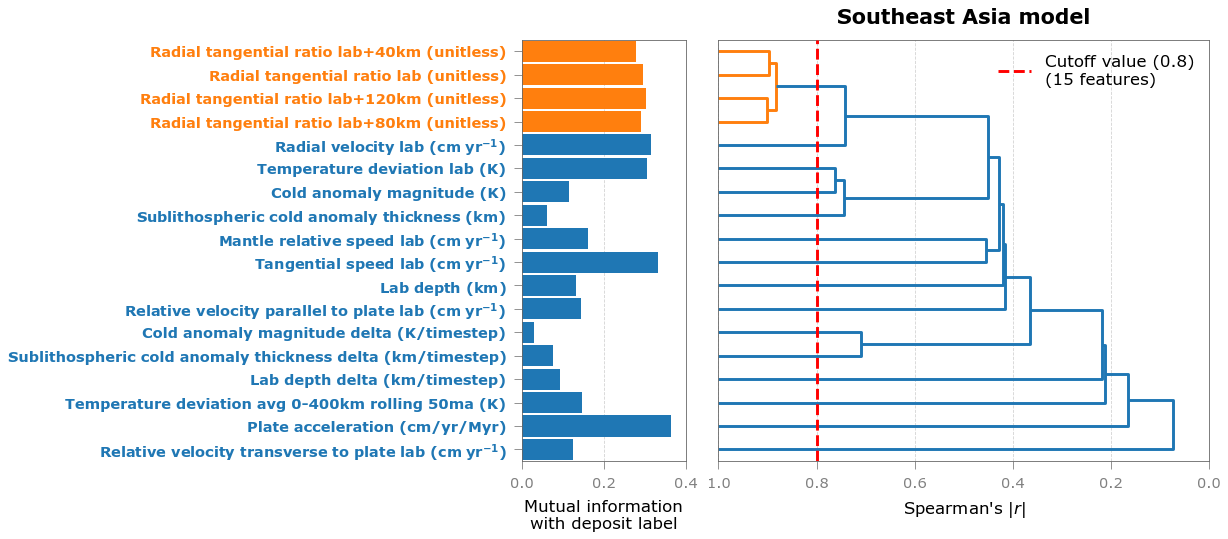

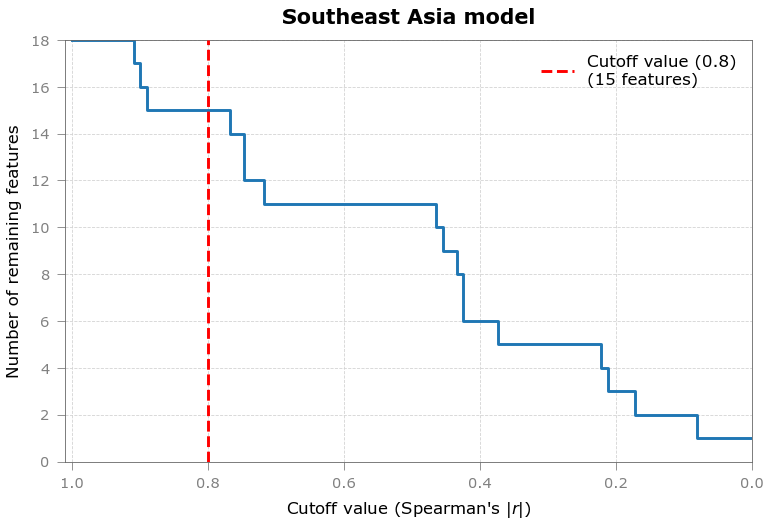

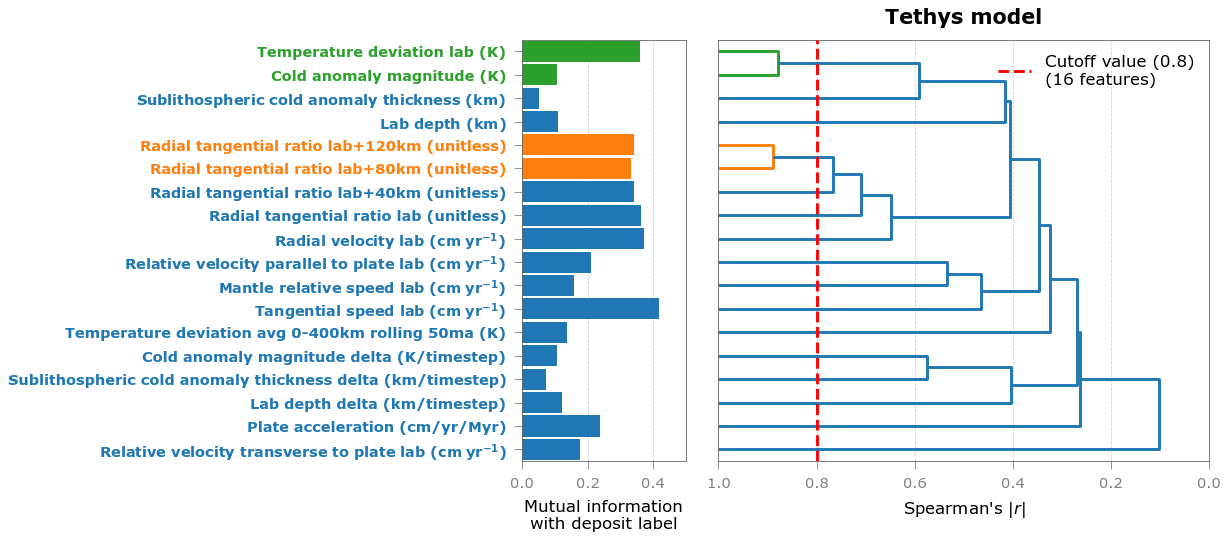

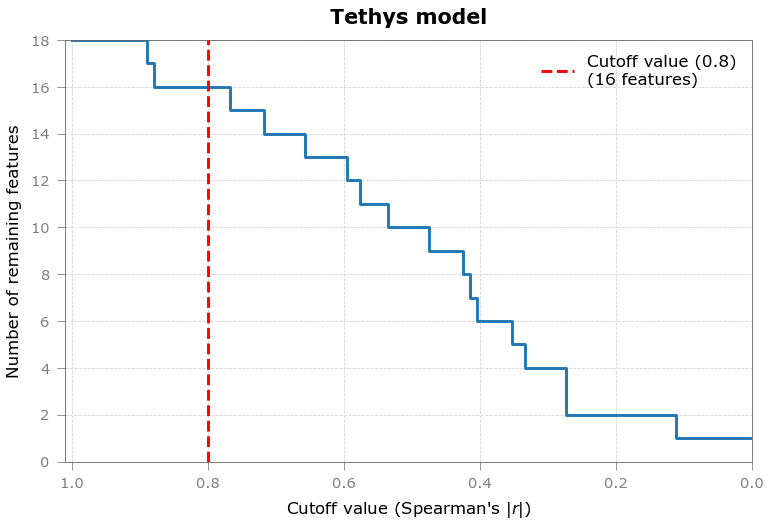

In [ ]:
clusters_regions = {}
mi_series_regions = {}
if create_regional_models:
    for region, subset in data.groupby("region"):
        region = str(region)
        if (subset["label"] == "positive").sum() < 50:
            print(f"Skipping region: {region}")
            continue
        subset = subset.drop(
            columns=list(COLUMNS_TO_DROP | PRESERVATION_COLUMNS | component_columns),
            errors="ignore",
        )
        r = "_".join(region.lower().split())

        print(f"Region: {region}")
        subset = subset[subset["label"].isin({"positive", "unlabelled"})]
        print(subset.groupby("label").size())
        x_pu_subset = subset.drop(columns="label")
        y_pu_subset = subset["label"].replace({"positive": 1, "unlabelled": 0}).astype("int")
        preprocessing_subset = clone(preprocessing).fit(x_pu_subset)
        fnames_subset = preprocessing_subset.get_feature_names_out()
        X_preprocessed_subset = preprocessing_subset.transform(x_pu_subset)

        Z_subset = linkage(
            X_preprocessed_subset.T,
            method="single",
            metric=lambda x, y: 1.0 - np.abs(spearmanr(x, y).statistic),
        )

        cluster_ids_subset = fcluster(Z_subset, cluster_threshold, criterion="distance")
        clusters_subset = {
            cluster_id: list(fnames_subset[cluster_ids_subset == cluster_id])
            for cluster_id in np.unique(cluster_ids_subset)
        }
        clusters_regions[region] = clusters_subset

        mi_scores_subset = mutual_info_classif(
            X_preprocessed_subset,
            y_pu_subset,
            random_state=random_seed,
        )
        p_subset = y_pu_subset.mean()
        mi_normalised_subset = mi_scores_subset / scipy_entropy([p_subset, 1 - p_subset])
        mi_series_regions[region] = pd.Series(mi_normalised_subset, index=fnames_subset)

        mi_dendrogram_filename_subset = figures_dir / f"mi_dendrogram_{r}"
        plot_combined(Z_subset, clusters_subset, mi_series_regions[region], fnames_subset, title=f"{region} model", filename=mi_dendrogram_filename_subset)

        thresh_clusters_subset = np.array([
            len(np.unique(fcluster(Z_subset, 1 - t, criterion="distance")))
            for t in thresh_vals
        ])

        # Cutoff vs. number of features
        cutoff_nfeatures_filename_subset = figures_dir / f"cutoff_nfeatures_{r}"
        fig, ax = plt.subplots()
        ax.step(thresh_vals, thresh_clusters_subset, where="post")
        ax.axvline(
            cutoff_value,
            linestyle="dashed",
            color="red",
            zorder=10,
            label=f"Cutoff value ({cutoff_value:0.1f})\n({len(clusters_subset)} features)",
        )
        ax.set_xlim(thresh_vals.max() * 1.01, thresh_vals.min())
        ax.set_ylim(0, None)
        ax.grid(linestyle="dashed", color="lightgrey")
        ax.legend(loc="best")
        ax.set_xlabel(r"Cutoff value (Spearman's $|r|$)")
        ax.set_ylabel("Number of remaining features")
        ax.set_title(f"{region} model")

        for ext in (".pdf", ".png"):
            fig.savefig(f"{cutoff_nfeatures_filename_subset}{ext}", dpi=350, bbox_inches="tight")

In [ ]:
if create_regional_models:
    for region, clusters_subset in clusters_regions.items():
        print(f"{region}:")
        for cluster_id in sorted(clusters_subset.keys()):
            print(f"  Cluster #{cluster_id}:")
            for f in clusters_subset[cluster_id]:
                print(f"    - {f}")

East Asia:
  Cluster #1:
    - sublithospheric_cold_anomaly_thickness_delta (km/timestep)
  Cluster #2:
    - cold_anomaly_magnitude_delta (K/timestep)
  Cluster #3:
    - tangential_speed_lab (cm/yr)
  Cluster #4:
    - mantle_relative_speed_lab (cm/yr)
  Cluster #5:
    - radial_tangential_ratio_lab (unitless)
    - radial_tangential_ratio_lab+40km (unitless)
    - radial_tangential_ratio_lab+80km (unitless)
    - radial_tangential_ratio_lab+120km (unitless)
  Cluster #6:
    - radial_velocity_lab (cm/yr)
  Cluster #7:
    - cold_anomaly_magnitude (K)
    - temperature_deviation_lab (K)
  Cluster #8:
    - sublithospheric_cold_anomaly_thickness (km)
  Cluster #9:
    - lab_depth (km)
  Cluster #10:
    - relative_velocity_parallel_to_plate_lab (cm/yr)
  Cluster #11:
    - relative_velocity_transverse_to_plate_lab (cm/yr)
  Cluster #12:
    - plate_acceleration (cm/yr/Myr)
  Cluster #13:
    - lab_depth_delta (km/timestep)
  Cluster #14:
    - temperature_deviation_avg_0-400km_rolling

#### Feature selection

In [ ]:
# if create_regional_models:
if True:
    if use_same_features:
        print("Using same features for all models")
        selected_features_regions = {
            region: selected_features
            for region in clusters_regions.keys()
        }
    elif automatic_feature_selection:
        selected_features_regions = {
            region: [
                max(clusters_regions[region][i], key=lambda f: mi_series_regions[region].get(f, 0.0))
                for i in sorted(clusters_regions[region].keys())
            ]
            for region in clusters_regions.keys()
        }
    else:
        selected_features_regions = {
            "North America": [
                "trench_velocity_obliquity (degrees)",
                "trench_velocity_parallel (cm/yr)",
                "convergence_rate_parallel (cm/yr)",
                "subducting_plate_absolute_velocity_parallel (cm/yr)",
                "crustal_thickness_mean (m)",
                "crustal_thickness_min (m)",
                "trench_velocity_orthogonal (cm/yr)",
                "subducted_sediment_volume (m)",
                "slab_dip (degrees)",
                "slab_flux (m^2/yr)",
                "subducting_plate_absolute_velocity_orthogonal (cm/yr)",
                "total_water_thickness (m)",
                "sediment_thickness (m)",
                "seafloor_spreading_rate (km/Myr)",
                "distance_to_trench (km)",
                "total_carbon_density (t/m^2)",
                "distance_to_trench_edge (km)",
            ],
            "South America": [
                "trench_velocity_obliquity (degrees)",
                "trench_velocity_orthogonal (cm/yr)",
                "sediment_thickness (m)",
                "convergence_rate_parallel (cm/yr)",
                "slab_dip (degrees)",
                "subducted_sediment_volume (m)",
                "slab_flux (m^2/yr)",
                "subducting_plate_absolute_velocity_orthogonal (cm/yr)",
                "trench_velocity_parallel (cm/yr)",
                "crustal_thickness_mean (m)",
                "distance_to_trench_edge (km)",
                "seafloor_spreading_rate (km/Myr)",
                "crustal_thickness_min (m)",
                "distance_to_trench (km)",
                "total_carbon_density (t/m^2)",
            ],
            "Southeast Asia": [
                "sediment_thickness (m)",
                "seafloor_spreading_rate (km/Myr)",
                "trench_velocity_obliquity (degrees)",
                "trench_velocity_parallel (cm/yr)",
                "convergence_rate_parallel (cm/yr)",
                "subducting_plate_absolute_velocity_parallel (cm/yr)",
                "slab_dip (degrees)",
                "crustal_thickness_mean (m)",
                "crustal_thickness_median (m)",
                "crustal_thickness_min (m)",
                "subducted_sediment_volume (m)",
                "slab_flux (m^2/yr)",
                "subducting_plate_absolute_velocity_orthogonal (cm/yr)",
                "trench_velocity_orthogonal (cm/yr)",
                "distance_to_trench (km)",
                "total_carbon_density (t/m^2)",
                "distance_to_trench_edge (km)",
            ],
            "Tethys": [
                "convergence_rate_parallel (cm/yr)",
                "convergence_obliquity (degrees)",
                "subducting_plate_absolute_velocity_parallel (cm/yr)",
                "subducting_plate_absolute_obliquity (degrees)",
                "trench_velocity_obliquity (degrees)",
                "trench_velocity_parallel (cm/yr)",
                "subducted_sediment_volume (m)",
                "slab_flux (m^2/yr)",
                "subducting_plate_absolute_velocity_orthogonal (cm/yr)",
                "distance_to_trench_edge (km)",
                "crustal_thickness_mean (m)",
                "slab_dip (degrees)",
                "sediment_thickness (m)",
                "crustal_thickness_min (m)",
                "seafloor_spreading_rate (km/Myr)",
                "trench_velocity_orthogonal (cm/yr)",
                "total_carbon_density (t/m^2)",
                "distance_to_trench (km)",
            ]
        }

Using same features for all models
